In [ ]:
#--------------------
# FASTA CONCATENATION
#--------------------

import os

input1 = "base_data/genbank.fasta"
input2 = "base_data/refseq.fasta"
output = "entero_sequences.fasta"

with open(output, "w") as outfile:
    for infile_name in [input1, input2]:
        last_line_ended_with_newline = True
        
        with open(infile_name, "r") as infile:
            line = ""
            for line in infile:
                outfile.write(line)
            
            if line and not line.endswith("\n"):
                last_line_ended_with_newline = False
        
        if not last_line_ended_with_newline:
            outfile.write("\n")

In [ ]:
#--------------
# SPECIES SPLIT
#--------------

import os
from Bio import SeqIO

input_fasta = "D:/enterovirus_project/entero_sequences.fasta"
output_dir = "sorted_species"

keywords = ["alphacoxsackie", "alpharhino", "betacoxsackie", "betarhino", "cerhino", "coxsackiepol", "deconjuncti", "eibovi", "fitauri", "geswini", "hesimi", "idromi", "jesimi", "krodeni", "lesimi"]

os.makedirs(output_dir, exist_ok=True)

file_handles = {}
for kw in keywords:
    file_handles[kw] = open(os.path.join(output_dir, f"{kw}.fasta"), "w")
file_handles["unclassified"] = open(os.path.join(output_dir, "unclassified.fasta"), "w")

for record in SeqIO.parse(input_fasta, "fasta"):
    header_lower = record.description.lower()
    matched_key = "unclassified"
    for kw in keywords:
        if kw in header_lower:
            matched_key = kw
            break
            
    SeqIO.write(record, file_handles[matched_key], "fasta")

for handle in file_handles.values():
    handle.close()

In [ ]:
#-----------------------------
# MULTIPLE FASTA CONCATENATION
#-----------------------------

input_files = [
    "sorted_species/alpharhino.fasta", "species_sorted/betacoxsackie.fasta",
    "sorted_species/betarhino.fasta", "species_sorted/cerhino.fasta",
    "sorted_species/deconjuncti.fasta", "species_sorted/eibovi.fasta",
    "sorted_species/fitauri.fasta", "species_sorted/geswini.fasta",
    "sorted_species/hesimi.fasta", "species_sorted/idromi.fasta",
    "sorted_species/jesimi.fasta", "species_sorted/krodeni.fasta",
    "sorted_species/lesimi.fasta", "species_sorted/unclassified.fasta"
]
output_file = "splitstree/rest.fasta"

translation = str.maketrans("/-.)(", "_____")

with open(output_file, "w") as outfile:
    for infile_name in input_files:
        line = ""
        with open(infile_name, "r") as infile:
            for line in infile:
                if line.startswith(">"):
                    line = line.translate(translation)
                outfile.write(line)
        
        if line and not line.endswith("\n"):
            outfile.write("\n")

In [2]:
#-----------------------------------------------
# "_refseq" / "_centroid" FASTA HEADER EXTENSION
#-----------------------------------------------

def splitstree_header_prep(input, reference, output):
    reference_headers = []
    with open(reference, 'r') as ref:
        for line in ref:
            if line.startswith(">"):
                ref_header = line.strip()[1:]
                if ref_header:
                    reference_headers.append(ref_header)
    
    with open(input, 'r') as infile, open(output, 'w') as outfile:
        for line in infile:
            if line.startswith(">"):
                header = line.strip()[1:]
                new_header = header
                
                if any(ref_h in header for ref_h in reference_headers):
                    new_header += "_centroid"
                    
                if "NC_" in header:
                    new_header += "_refseq"
                    
                outfile.write(f">{new_header}\n")
            else:
                outfile.write(line)
                
splitstree_header_prep(
    input = "splitstree/alphacoxsackie_aligned.fasta", 
    reference = "viralclust_results/alphacoxsackie_positive_nr_cdhitest.fasta", 
    output = "splitstree/alphacoxsackie_splitstree.fasta"
)

splitstree_header_prep(
    input="splitstree/coxsackiepol_aligned.fasta",
    reference="viralclust_results/coxsackiepol_positive_nr_hdbscan.fasta",
    output="splitstree/coxsackiepol_splitstree.fasta"
)

splitstree_header_prep(
    input="splitstree/rest_aligned.fasta",
    reference="viralclust_results/rest_positive_nr_hdbscan.fasta",
    output="splitstree/rest_splitstree.fasta"
)

In [1]:
#--------------------
# NEXUS FILE CLEANING
#--------------------

import re

def nexus_cleaning(input, output):
    pattern = re.compile(r'\bs=(-?\d+\.?\d*)\b')
    
    def cap_s_values(match):
        val_str = match.group(1)
        try:
            val = float(val_str)
            if val > 10000:
                return "s=10000"
            elif val < -10000:
                return "s=-10000"
        except ValueError:
            pass
        return f"s={val_str}"
    
    with open(input, 'r', encoding='utf-8', errors='ignore') as infile, \
         open(output, 'w', encoding='utf-8') as outfile:
        
        for line in infile:
            new_line = pattern.sub(cap_s_values, line)
            outfile.write(new_line)
            
nexus_cleaning("splitstree/alphacoxsackie_splitstree.nex", "splitstree/alphacoxsackie_splitstree_cleaned.nex")
nexus_cleaning("splitstree/coxsackiepol_splitstree.nex", "splitstree/coxsackiepol_splitstree_cleaned.nex")

In [1]:
#------------------------------------------------
# ADD ALPHACOXSACKIE & COXSACKIEPOL TO rest.fasta 
#------------------------------------------------

import os

def read_fasta(file_path, filter_function=None):
    sequences = []
    
    with open(file_path, "r") as f:
        current_header = ""
        current_sequence = []
        
        for row in f:
            row = row.strip()
            if not row:
                continue
            if row.startswith(">"):
                if current_header:
                    if filter_function is None or filter_function(current_header):
                        sequences.append((current_header, "".join(current_sequence)))
                current_header = row
                current_sequence = []
            else:
                current_sequence.append(row)
        
        if current_header:
            if filter_function is None or filter_function(current_header):
                sequences.append((current_header, "".join(current_sequence)))
                
    return sequences

input = "splitstree/OLD_rest_splitstree.fasta"
a_add = "splitstree/alphacoxsackie_splitstree.fasta"
c_add = "splitstree/coxsackiepol_splitstree.fasta"
output = "splitstree/rest.fasta"

def is_relevant(header):
    return "_centroid" in header or "_refseq" in header

all_sequences = read_fasta(input)

seqs_a_add = read_fasta(a_add, filter_function=is_relevant)
all_sequences.extend(seqs_a_add)

seqs_c_add = read_fasta(c_add, filter_function=is_relevant)
all_sequences.extend(seqs_c_add)

os.makedirs(os.path.dirname(output), exist_ok=True)

del_with_gaps = 0
with open(output, "w") as out:
    for header, seq in all_sequences:
        seq_wo_gaps = seq.replace("-", "")
        
        out.write(f"{header}\n{seq_wo_gaps}\n")
        del_with_gaps += 1

In [2]:
#-------------------------
# REPRESENTATIVE SELECTION
#-------------------------
import os
import glob

input_dir = "splitstree/"
output_file = "entero_representatives.fasta"

search_pattern = os.path.join(input_dir, "*_splitstree.fasta")
fasta_files = glob.glob(search_pattern)

sequences = 0

with open(output_file, "w") as out:
    for file_path in fasta_files:
        with open(file_path, "r") as infile:
            current_header = ""
            current_sequence = []
            
            for row in infile:
                if row.startswith(">"):
                    if current_header and ("_centroid" in current_header or "_refseq" in current_header):
                        sequence_string = "".join(current_sequence)
                        
                        sequence_no_gaps = sequence_string.replace("-", "")
                        out.write(current_header + sequence_no_gaps)
                        
                        sequences += 1
                    
                    current_header = row
                    current_sequence = []
                else:
                    current_sequence.append(row)
            
            if current_header and ("_centroid" in current_header or "_refseq" in current_header):
                sequence_string = "".join(current_sequence)
                
                sequence_no_gaps = sequence_string.replace("-", "")
                out.write(current_header + sequence_no_gaps)
                
                sequences += 1
                
print(f"Done! {sequences} representative genomes selected and saved as {output_file}")

In [6]:
#---------------------------
# REPRESENTATIVES MANUAL ADD
#---------------------------

input = "entero_sequences.fasta"
output = "entero_representatives_test.fasta"

target_strings = [
    "HQ647170", "AF326751", "MW384881", "AY421764", "D00625", "PP068135", "GU390707",
    "AJ132961", "KU372652", "MN914203", "MH144606", "HQ415759", "AF499636", "OR129531"
]

added_seqs = 0

with open(output, "a") as outfile, open (input, "r") as infile:
    
    copy_active = False
    
    for row in infile:
        if row.startswith(">"):
            if any(target_string in row for target_string in target_strings):
                copy_active = True
                
                new_header = row.strip() + "_manually\n"
                
                outfile.write(new_header)
                added_seqs += 1
            else:
                copy_active = False
        else:
            if copy_active:
                outfile.write(row)
                
print(f"Done! {added_seqs} sequences added")

Done! 14 sequences added


In [1]:
#-------------
# GFF FETCHING
#-------------

from Bio import Entrez
import re
import time
import os

Entrez.email = "ug71jodi@studserv.uni-leipzig.de"
input = "entero_representatives.fasta"

def ids_from_fasta(filepath):
    ids = []
    pattern = re.compile(r"^([A-Z]{2}_?\d+\.\d+)")

    with open(filepath, "r") as f:
        for line in f:
            if line.startswith(">"):
                header = line[1:].strip().split()[0]
                match = pattern.search(header)
                if match:
                    entry = match.group(1).replace("/", "_")
                    ids.append(entry)
                else:
                    ids.append(header.replace("/", "_"))
    return ids

def gff_fetching(id_list, output = "gff_files"):
    if not os.path.exists(output):
        os.makedirs(output)

    for acc in id_list:
        target_path = os.path.join(output, f"{acc}.gff")

        if os.path.exists(target_path):
            print(f"Skipping {acc} (already existing).")
            continue

        print(f"Downloading GFF for {acc}")
        try:
            handle = Entrez.efetch(db="nucleotide", id=acc, rettype="gff3", retmode="text")
            with open(target_path, "w") as f:
                f.write(handle.read())
            handle.close()
            time.sleep(0.3)
        except Exception as e:
            print(f"Error at {acc}: {e}")

accessions = ids_from_fasta(input)
print(f"{len(accessions)} sequences in alignment found")
gff_fetching(accessions)

249 sequences in alignment found


In [10]:
#-------------------------
# ADJUST READING DIRECTION
#-------------------------

input = "SAVEFILE_entero_representatives.fasta"
output = "entero_representatives.fasta"
target_strings = ["HQ647170"]

complement_table = str.maketrans("ATGCatgc", "TACGtacg")

reversed_seqs = 0
total_seqs = 0

with open(input, "r") as infile, open(output, "w") as outfile:
    current_header = ""
    current_seq = []
    
    for row in infile:
        row = row.strip()
        
        if row.startswith(">"):
            if current_header:
                seq_string = "".join(current_sequence)
                total_seqs += 1
                
                if any(target_string in current_header for target_string in target_strings):
                    seq_string = seq_string[::-1].translate(complement_table)
                    reversed_seqs += 1
                    
                outfile.write(f"{current_header}\n{seq_string}\n")
                
            current_header = row
            current_sequence = []
        else:
            current_sequence.append(row)
    
    if current_header:
        seq_string = "".join(current_sequence)
        total_seqs += 1
        
        if any(target_string in row for target_string in target_strings):
            seq_string = seq_string[::-1].translate(complement_table)
            reversed_seqs += 1
        
        outfile.write(f"{current_header}\n{seq_string}\n")

print(f"Total sequences checked:\t{total_seqs}")
print(f"Sequences reversed:\t{reversed_seqs}")
print(f"Result saved in:\t{output}")

Total sequences checked:	249
Sequences reversed:	1
Result saved in:	entero_representatives.fasta


In [1]:
#---------------------
# ANCHORNA PREPARATION 
#---------------------

from sugar import read
from sugar._io.gff import read_fts_gff
from pathlib import Path

fasta_file = "entero_subseq_representatives.fasta"
gff_dir = Path("gff_files")
output_file = "anchors.gff"

available_gffs = {f.stem: f for f in gff_dir.glob("*.gff")}

seqs = read(str(fasta_file))
basket = read()
basket.clear()

for s in seqs:
    s.str.replace('-', '')
    s.id = s.id.strip()
    s.meta.id = s.id
    
    matched_id = next((gid for gid in available_gffs if gid in s.id), None)
    
    if matched_id:
        gff_path = available_gffs[matched_id]
        with open(gff_path, 'r') as f:
            features = read_fts_gff(f)
        
        if features:
            valid_fts = []
            for ft in features:
                if ft.type in ["region", "gene"]:
                    continue
                
                if ft.type == "mature_protein_region_of_CDS" or ft.type == "CDS":
                    ft.type = "CDS"
                
                ft.seqid = s.id
                valid_fts.append(ft)
            
            if valid_fts:
                s.fts = valid_fts
                basket.append(s)

basket.write(str(output_file), fmt='gff')

print(f"Done! Input for AnchoRNA saved as {output_file}")

Done! Input for AnchoRNA saved as anchors.gff


In [1]:
#---------------------------------
# LOCARNA PREPARATION METHOD 1 
# Subsequences cut between anchors
#---------------------------------

import pandas as pd
from collections import defaultdict
import os

gff_file = "anchors.gff"
fasta_file = "entero_subseq_representatives.fasta"
gff_dir = "gff_files"
output_dir = "subsequences"
min_length = 0

def read_fasta(file):
    sequences = {}
    current_header = ""
    current_seq = []
    with open(file, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if current_header:
                    sequences[current_header] = "".join(current_seq)
                current_header = line[1:].split()[0]
                current_seq = []
            else:
                current_seq.append(line)
        if current_header:
            sequences[current_header] = "".join(current_seq)
    return sequences

fasta_seqs = read_fasta(fasta_file)

offsets = {}
gff_data = []

with open(gff_file, "r") as f:
    for line in f:
        if line.startswith("#offset"):
            parts = line.strip().split()
            if len(parts) >= 3:
                offsets[parts[1]] = int(parts[2])
        elif not line.startswith("#"):
            parts = line.strip().split("\t")
            if len(parts) >= 9:
                gff_data.append(parts)
                
df = pd.DataFrame(gff_data, columns = ['seq_id', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase', 'attributes'])
df["start"] = df["start"].astype(int)
df["end"] = df["end"].astype(int)

df["anchor_nr"] = df["attributes"].str.extract(r"Name=(A\d+)")

seq_anchors = defaultdict(dict)
for _, row in df.iterrows():
    if pd.notnull(row["anchor_nr"]):
        seq_anchors[row["seq_id"]][row["anchor_nr"]] = (row["start"], row["end"])

unique_anchors = sorted(list(df["anchor_nr"].dropna().unique()), key = lambda x: int(x[1:]))

three_utr_starts = {}

gff_files = [f for f in os.listdir(gff_dir) if f.endswith(".gff") if f.endswith(".gff")]
for s_id in fasta_seqs.keys():
    matched_gff = None
    
    for gff in gff_files:
        base_name = gff.replace(".gff", "")
        if base_name in s_id:
            matched_gff = os.path.join(gff_dir, gff)
            break
            
    if matched_gff:
        explicit_utr_start = None
        max_cds_end = 0
        
        with open(matched_gff, "r") as f:
            for line in f:
                if line.startswith("#"): continue
                parts = line.strip().split("\t")
                if len(parts) >= 5:
                    feature_type = parts[2]
                    try:
                        start_pos = int(parts[3])
                        end_pos = int(parts[4])
                    except ValueError:
                        continue
                    
                    if feature_type == "three_prime_UTR":
                        explicit_utr_start = start_pos
                    elif feature_type == "CDS":
                        if end_pos > max_cds_end:
                            max_cds_end = end_pos
        
        if explicit_utr_start is not None:
            three_utr_starts[s_id] = explicit_utr_start - 1
        elif max_cds_end > 0:
            three_utr_starts[s_id] = max_cds_end

os.makedirs(output_dir, exist_ok=True)

all_regions = ["5UTR"] + [f"{unique_anchors[i]}_{unique_anchors[i+1]}" for i in range(len(unique_anchors) - 1)] + ["3UTR"]

for region in all_regions:
    extracted_seqs = {}
    
    for s_id, full_seq in fasta_seqs.items():
        anchors = seq_anchors.get(s_id, {})
        offset = offsets.get(s_id, 0)
        subseq = ""
        
        if region == "5UTR":
            if unique_anchors[0] in anchors:
                start_aa, _ = anchors[unique_anchors[0]]
                nt_pos_end = offset + ((start_aa - 1) * 3)
                subseq = full_seq[:nt_pos_end]
        
        elif region == "3UTR":
            if s_id in three_utr_starts:
                nt_pos_start = three_utr_starts[s_id]
                subseq = full_seq[nt_pos_start:]
                
        else:
            a_curr, a_next = region.split("_")
            if a_curr in anchors and a_next in anchors:
                _, end_curr_aa = anchors[a_curr]
                start_next_aa, _ = anchors[a_next]
                
                nt_start = offset + (end_curr_aa * 3)
                nt_end = offset + ((start_next_aa - 1) * 3)
                subseq = full_seq[nt_start:nt_end]
        
        if len(subseq) >= min_length:
            extracted_seqs[s_id] = subseq
    
    if len(extracted_seqs) > 1:
        out_name = os.path.join(output_dir, f"{region}.fasta")
        with open(out_name, "w") as f:
            for s_id, s_seq in extracted_seqs.items():
                f.write(f">{s_id}\n{s_seq}\n")
        #print(f"Region {region}: {len(extracted_seqs)} sequences extracted")

print(f"Done! Subsequences saved in {output_dir}")

Done! Subsequences saved in subsequences


In [2]:
#-----------------------------------
# LOCARNA PREPARATION METHOD 2
# Subsequences with included anchors 
#-----------------------------------

import pandas as pd
from collections import defaultdict
import os

gff_file = "anchors.gff"
fasta_file = "entero_subseq_representatives.fasta"
output_dir = "subsequences"
buffer = 0

def read_fasta(file):
    seqs = {}
    with open(file, 'r') as f:
        header = ""
        for line in f:
            if line.startswith(">"):
                header = line[1:].split()[0]
                seqs[header] = ""
            else:
                seqs[header] += line.strip()
    return seqs

fasta_seqs = read_fasta(fasta_file)

offsets = {}
gff_data = []
with open(gff_file, "r") as f:
    for line in f:
        if line.startswith("#offset"):
            parts = line.strip().split()
            offsets[parts[1]] = int(parts[2])
        elif not line.startswith("#"):
            gff_data.append(line.strip().split("\t"))
                
df = pd.DataFrame(gff_data, columns = ["seq_id", "source", "type", "start", "end", "score", "strand", "phase", "attributes"])
df["start"] = df["start"].astype(int)
df["end"] = df["end"].astype(int)
df["anchor_id"] = df["attributes"].str.extract(r"Name=(A\d+)")

seq_anchors = defaultdict(dict)
for _, row in df.iterrows():
    if pd.notnull(row['anchor_id']):
        offset = offsets.get(row['seq_id'], 0)
        nt_start = offset + (row['start'] - 1) * 3
        nt_end = offset + (row['end'] * 3)
        
        if (nt_end - nt_start) > 36:
            nt_end = nt_start + 36
        
        seq_anchors[row['seq_id']][row['anchor_id']] = (nt_start, nt_end)

os.makedirs(output_dir, exist_ok=True)
unique_anchors = sorted(list(df['anchor_id'].dropna().unique()), key = lambda x: int(x[1:]))

def generate_locarna_lines(sub_seq, anchor_data, start_idx):
    line1 = ["."] * len(sub_seq)
    line2 = ["."] * len(sub_seq)
    
    for nt_s, nt_e, label in anchor_data:
        local_s = nt_s - start_idx
        local_e = nt_e - start_idx
        
        symbols = list("0123456789abcdefghijklmnopqrstuvwxyz")

        counter = 0
        for j in range(local_s, local_e):
            if 0 <= j < len(sub_seq):
                line1[j] = label
                line2[j] = symbols[counter]
                counter += 1
    return "".join(line1) + " #1", "".join(line2) + " #2"


if offsets:
    lines_5utr = []
    for s_id, full_seq in fasta_seqs.items():
        if s_id in offsets:
            end_idx = offsets[s_id] 
            sub = full_seq[0:end_idx]
            l1, l2 = generate_locarna_lines(sub, [], 0)
            lines_5utr.extend([f">{s_id}", sub, l1, l2])
    if lines_5utr:
        with open(os.path.join(output_dir, "5UTR.fasta"), "w") as f:
            f.write("\n".join(lines_5utr) + "\n")


for i in range(len(unique_anchors) - 1):
    id_a, id_b = unique_anchors[i], unique_anchors[i+1]
    lines = []
    for s_id, full_seq in fasta_seqs.items():
        if id_a in seq_anchors[s_id] and id_b in seq_anchors[s_id]:
            pos_a, pos_b = seq_anchors[s_id][id_a], seq_anchors[s_id][id_b]
            start_idx = max(0, pos_a[0] - buffer)
            end_idx = min(len(full_seq), pos_b[1] + buffer)
            sub = full_seq[start_idx:end_idx]
            l1, l2 = generate_locarna_lines(sub, [(pos_a[0], pos_a[1], "A"), (pos_b[0], pos_b[1], "B")], start_idx)
            lines.extend([f">{s_id}", sub, l1, l2])
    if lines:
        with open(f"{output_dir}/{id_a}_{id_b}.fasta", "w") as f:
            f.write("\n".join(lines) + "\n")

if unique_anchors:
    a_id = unique_anchors[-1]
    lines = []
    
    for s_id, full_seq in fasta_seqs.items():
        if a_id in seq_anchors[s_id]:
            end_pos = df[(df['seq_id'] == s_id) & (df['anchor_id'] == a_id)]['end'].values[0]
            offset = offsets.get(s_id, 0)
            
            start_idx = offset + (end_pos * 3) + 3 + 1
            
            sub = full_seq[start_idx:]
            
            l1, l2 = generate_locarna_lines(sub, [], 0)
            lines.extend([f">{s_id}", sub, l1, l2])
            
    if lines:
        with open(os.path.join(output_dir, "3UTR.fasta"), "w") as f:
            f.write("\n".join(lines) + "\n")

print(f"Done! Subsequences saved in {output_dir}")

Done! Subsequences saved in subsequences


In [ ]:
#---------------------------
# 3' UTR LENGTH DISTRIBUTION
#---------------------------

import os
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO

fasta_file = "D:/enterovirus_project/subsequences/3UTR.fasta"
output_plot = "D:/enterovirus_project/Abbildungen/3UTR_length_distribution.png"

lengths = []
for record in SeqIO.parse(fasta_file, "fasta"):
    clean_seq = str(record.seq).replace("-", "")
    lengths.append(len(clean_seq))

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.histplot(lengths, kde=True, bins=25, color='#2ca02c', edgecolor='black', alpha=0.7)

amount = len(lengths)
min_l = min(lengths)
max_l = max(lengths)
mean_l = sum(lengths) / amount

plt.title(f"Length Distribution of 3' UTR (n = {amount})", fontsize=14, pad=15)
plt.xlabel("Sequence Length (nt)", fontsize=12)
plt.ylabel("Amount of Sequences", fontsize=12)

plt.axvline(mean_l, color='red', linestyle='--', linewidth=1.5, label=f"Mean = ({mean_l:.1f} nt)")
plt.legend()

plt.tight_layout()
plt.savefig(output_plot, dpi=300)
plt.show()

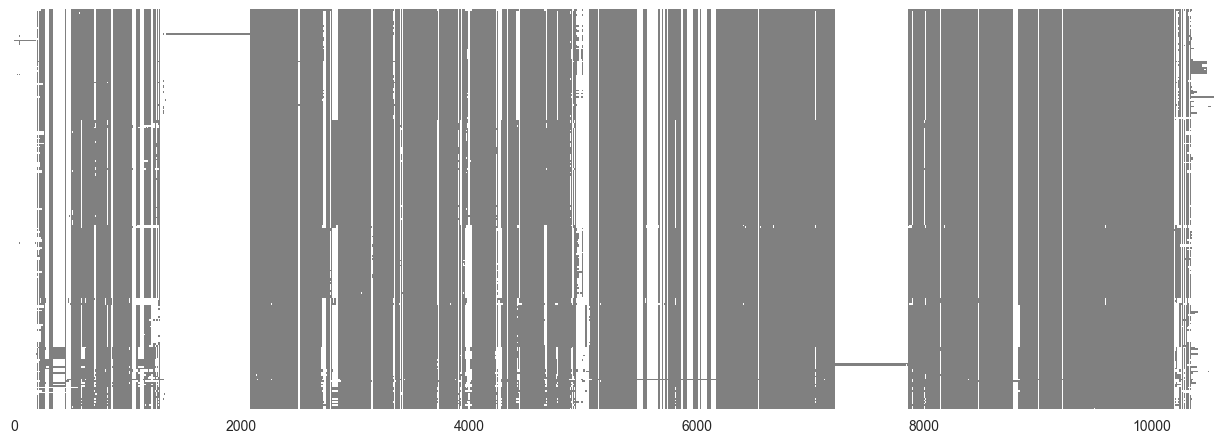

<Axes: >

In [11]:
#--------------------------
# GLOBAL SEQUENCE ALIGNMENT
#--------------------------

from sugar import read

fasta_file = "entero_representatives_aligned_G-INS-i.fasta"

seqs = read(fasta_file)
seqs.plot_alignment(show=True, color='gray', figsize=(12, 4))